<a href="https://colab.research.google.com/github/1Anisa1/ComputerVisionPractice/blob/main/CV_Exam_Anisa_Tabaku.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exam Computer Vision 2026 - Anisa Tabaku - IAO++

1. Load and visualize the 'coins' image from the skimage built-in datasets. Report the size of the image and range of the pixel grayscale levels.

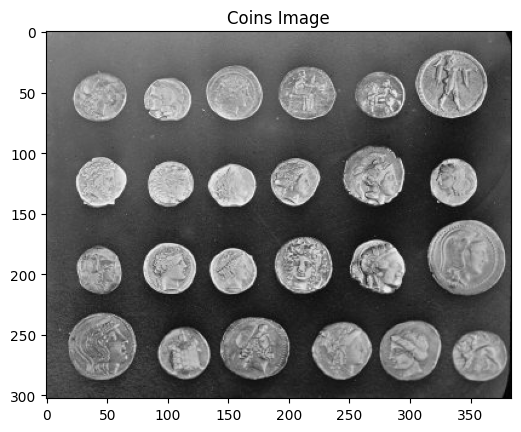

Image dimensions: (303, 384)
Lowest grayscale value: 1
Highest grayscale value: 252


In [191]:
import matplotlib.pyplot as plt
from skimage import data

image = data.coins()

plt.figure(figsize=(6,6))
plt.imshow(image, cmap='gray')
plt.title('Coins Image')
plt.axis('on')
plt.show()

print("Image dimensions:", image.shape)
print("Lowest grayscale value:", image.min())
print("Highest grayscale value:", image.max())

2. Represent the histogram of the image. Explain the peaks of the histogram in terms of regions of the image.


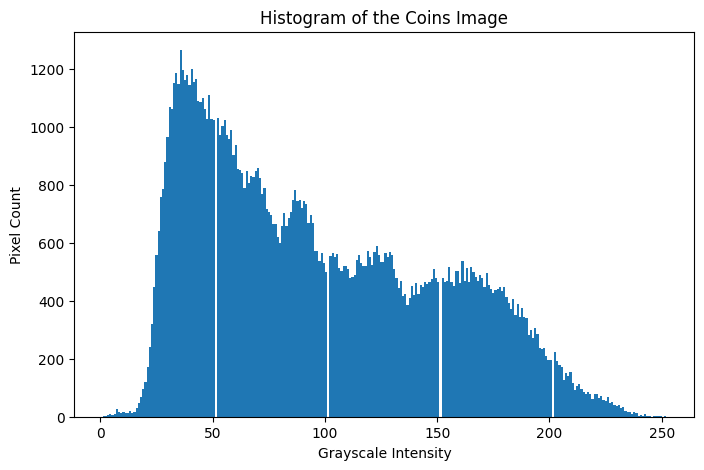

In [192]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(image.ravel(), bins=256)

plt.title('Histogram of the Coins Image')
plt.xlabel('Grayscale Intensity')
plt.ylabel('Pixel Count')

plt.show()

The histogram represents the distribution of grayscale values in the coins image. It shows how many pixels exist for each intensity level, ranging from black (0) to white (255). The peaks in the histogram correspond to areas of the image that contain many pixels with similar brightness levels. In the coins image, the darker peaks are mainly associated with the background and shadowed regions, while the medium and brighter intensity values correspond to the coins and their shiny or reflective surfaces.


3. Applied noise to the image and use the correct function to erase the noise.

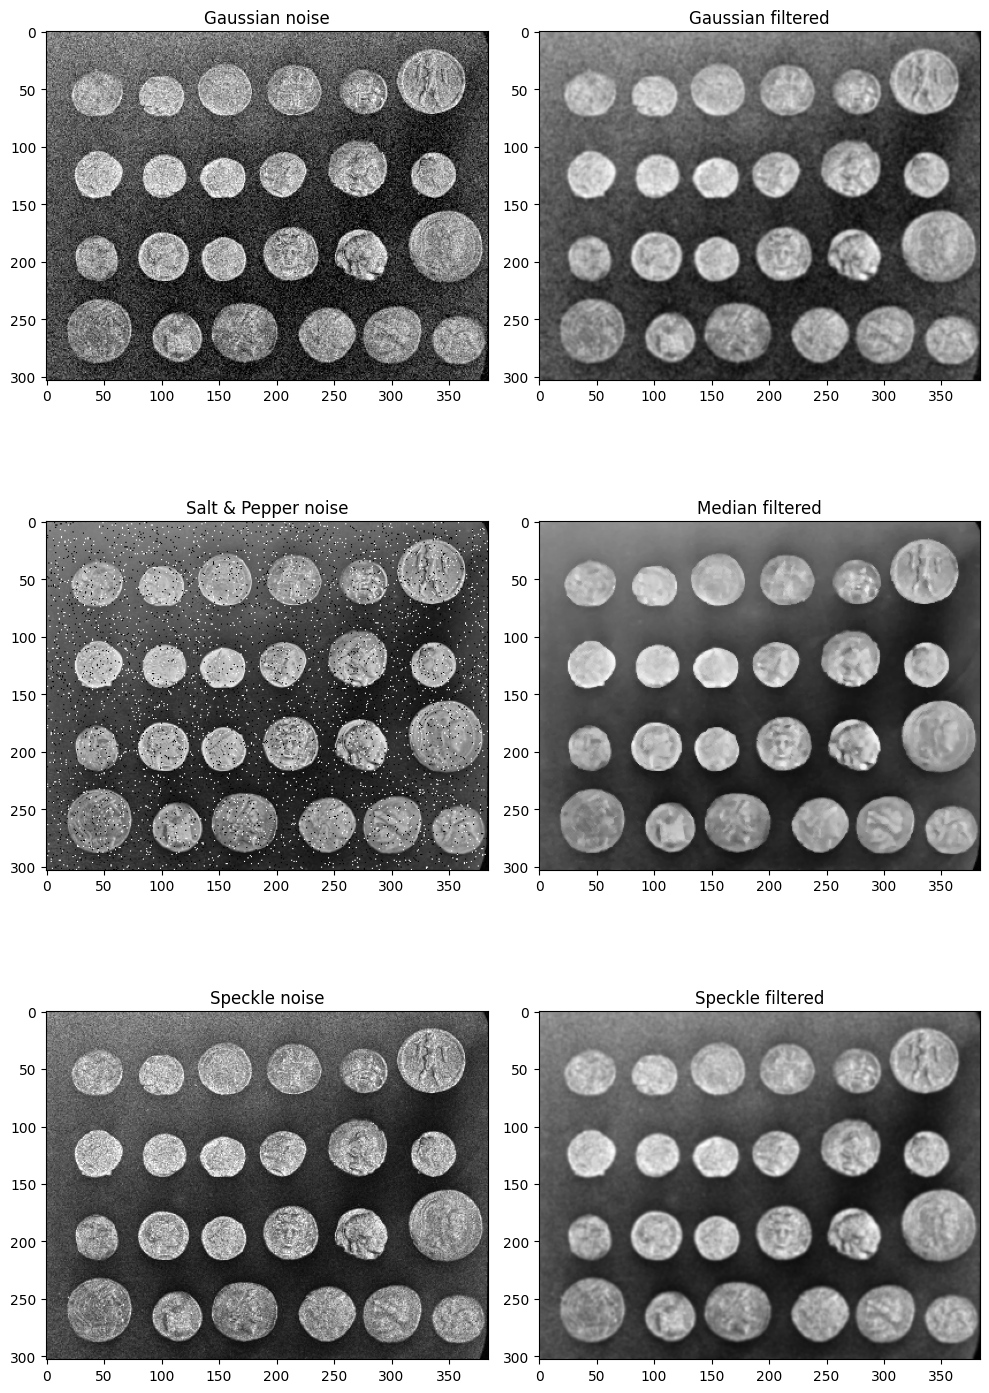

In [183]:
from skimage.util import random_noise
from skimage.filters import gaussian, median
from skimage.morphology import disk
import matplotlib.pyplot as plt

gaussian_noise = random_noise(image, mode='gaussian', var=0.01)
sp_noise = random_noise(image, mode='s&p', amount=0.05)
speckle_noise = random_noise(image, mode='speckle', var=0.02)

gaussian_filtered = gaussian(gaussian_noise, sigma=1)
sp_filtered = median(sp_noise, footprint=disk(2))
speckle_filtered = gaussian(speckle_noise, sigma=1)

fig, ax = plt.subplots(3,2, figsize=(10,15))

titles = ['Gaussian noise', 'Gaussian filtered',
          'Salt & Pepper noise', 'Median filtered',
          'Speckle noise', 'Speckle filtered']

images = [gaussian_noise, gaussian_filtered,
          sp_noise, sp_filtered,
          speckle_noise, speckle_filtered]

for i in range(3):
    ax[i,0].imshow(images[2*i], cmap='gray')
    ax[i,0].set_title(titles[2*i])

    ax[i,1].imshow(images[2*i+1], cmap='gray')
    ax[i,1].set_title(titles[2*i+1])

plt.tight_layout()
plt.show()

In the coins image, Gaussian noise appears as smooth intensity variations distributed across neighboring pixels, so it is effectively reduced using a Gaussian filter. Salt and pepper noise introduces random black and white pixels over the image, and a median filter works best because it removes these isolated pixels while preserving the edges of the coins. Speckle noise creates random multiplicative variations in brightness on the coin surfaces, and it can also be reduced effectively with a Gaussian filter due to its spread-out appearance across the image.


4. Segment the image using a k-means clustering algorithm with k=2 and represent the

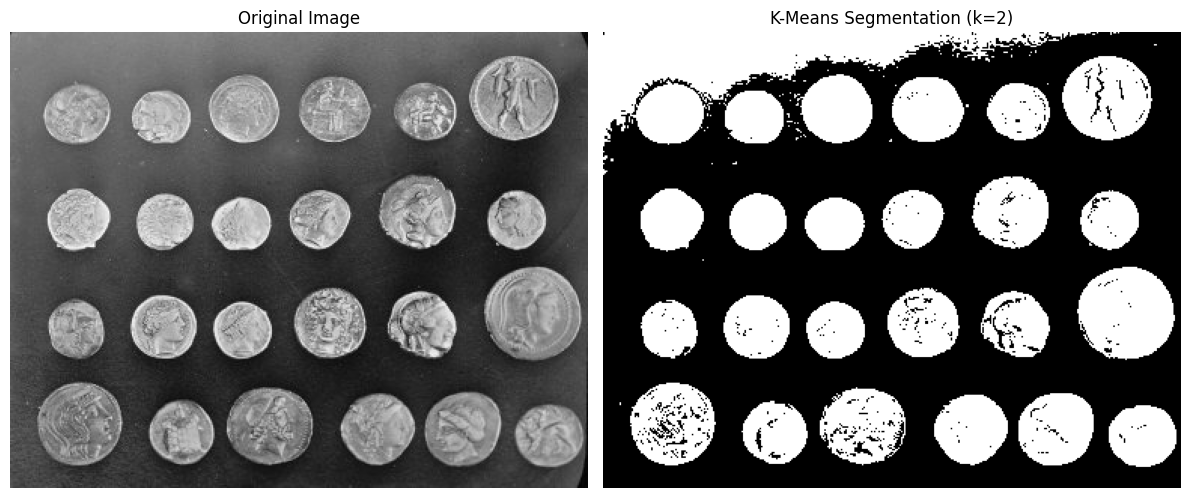

In [184]:
from sklearn.cluster import KMeans

v_image = image.reshape(image.shape[0] * image.shape[1], 1)

kmeans = KMeans(n_clusters=2, random_state=0)
labels = kmeans.fit_predict(v_image)

segmented = labels.reshape(image.shape)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

images = [image, segmented]
titles = ['Original Image', 'K-Means Segmentation (k=2)']

for i in range(2):
    ax[i].imshow(images[i], cmap='gray')
    ax[i].set_title(titles[i])
    ax[i].axis('off')

plt.tight_layout()
plt.show()

5. Label the objects found in the image. Generate a figure with the original image and the labeled image. How many coins are there in the image?

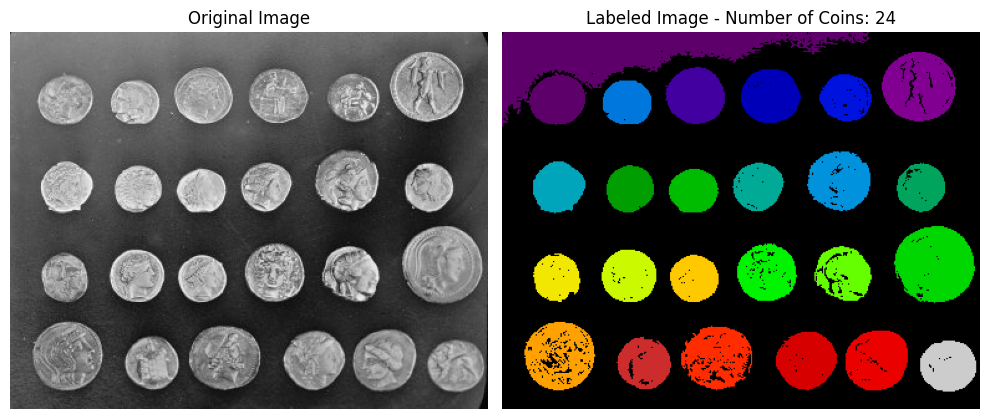

Number of coins in the image: 24


In [185]:
from skimage.filters import threshold_otsu
from skimage.measure import label
from skimage.morphology import remove_small_objects

threshold = threshold_otsu(image)
binary_coins = image > threshold

binary_coins_cleaned = remove_small_objects(binary_coins, min_size=100)

labeled_coins, num_coins = label(binary_coins_cleaned, return_num=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(labeled_coins, cmap='nipy_spectral')
axes[1].set_title(f'Labeled Image - Number of Coins: {num_coins}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f'Number of coins in the image: {num_coins}')

6. Extract the area, major axis length and orientation of each coin. Report the average values of the extracted features. Represent a scatterplot of the area vs major axis length

    label    area  axis_major_length  orientation
0       1  8755.0         291.294551    -1.423307
1       2  2459.0          59.966495     1.552547
2       3  1684.0          47.400067     1.330651
3       4  1631.0          47.608317     1.560757
4       5  1193.0          41.310433     1.383445
5       6  1133.0          39.977857     1.446910
6       7  1834.0          51.413541     1.532118
7       8  1325.0          42.451724    -0.883311
8       9  1203.0          40.921169    -1.034534
9      10  1133.0          39.719469    -0.873364
10     11  1129.0          39.179294    -0.923138
11     12  1104.0          39.634983    -1.500398
12     13  3054.0          64.238604     1.321690
13     14  1633.0          48.455200    -1.482099
14     15  1352.0          47.315544     0.943862
15     16  1461.0          44.279748     1.510757
16     17  1095.0          37.726049    -1.098781
17     18  1148.0          39.093268     1.512176
18     19  2099.0          58.230243    -1.108783


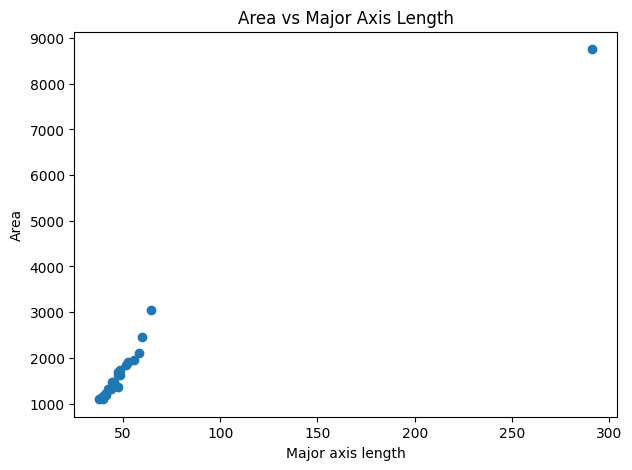

In [186]:
import pandas as pd
from skimage.measure import regionprops_table

properties = regionprops_table(
    labeled_coins,
    properties=['label', 'area', 'axis_major_length', 'orientation']
)

df_coins = pd.DataFrame(properties)

print(df_coins)

average_values = df_coins[['area', 'axis_major_length', 'orientation']].mean()

print("\nAverage area:", average_values['area'])
print("Average major axis length:", average_values['axis_major_length'])
print("Average orientation:", average_values['orientation'])

plt.figure(figsize=(7,5))

plt.scatter(df_coins['axis_major_length'], df_coins['area'])

plt.xlabel('Major axis length')
plt.ylabel('Area')
plt.title('Area vs Major Axis Length')

plt.show()

7. Using the labeled regions from the 'coins' image, how can I filter the regions to find those with an area greater than 1750 pixels, count how many such coins there are?




In [187]:
large_coins = df_coins[df_coins['area'] > 1750]

n_large_coins = len(large_coins)

print(large_coins)

print("\nNumber of coins with area greater than 1750 pixels:", n_large_coins)

    label    area  axis_major_length  orientation
0       1  8755.0         291.294551    -1.423307
1       2  2459.0          59.966495     1.552547
6       7  1834.0          51.413541     1.532118
12     13  3054.0          64.238604     1.321690
18     19  2099.0          58.230243    -1.108783
19     20  1954.0          55.822104    -1.406812
20     21  1918.0          52.847912    -0.985728

Number of coins with area greater than 1750 pixels: 7


8. Generate a 3-panel figure with the original image, the image with the little coins < 1750 coins (red color) and an image with the big coins > 1750 (blue color).

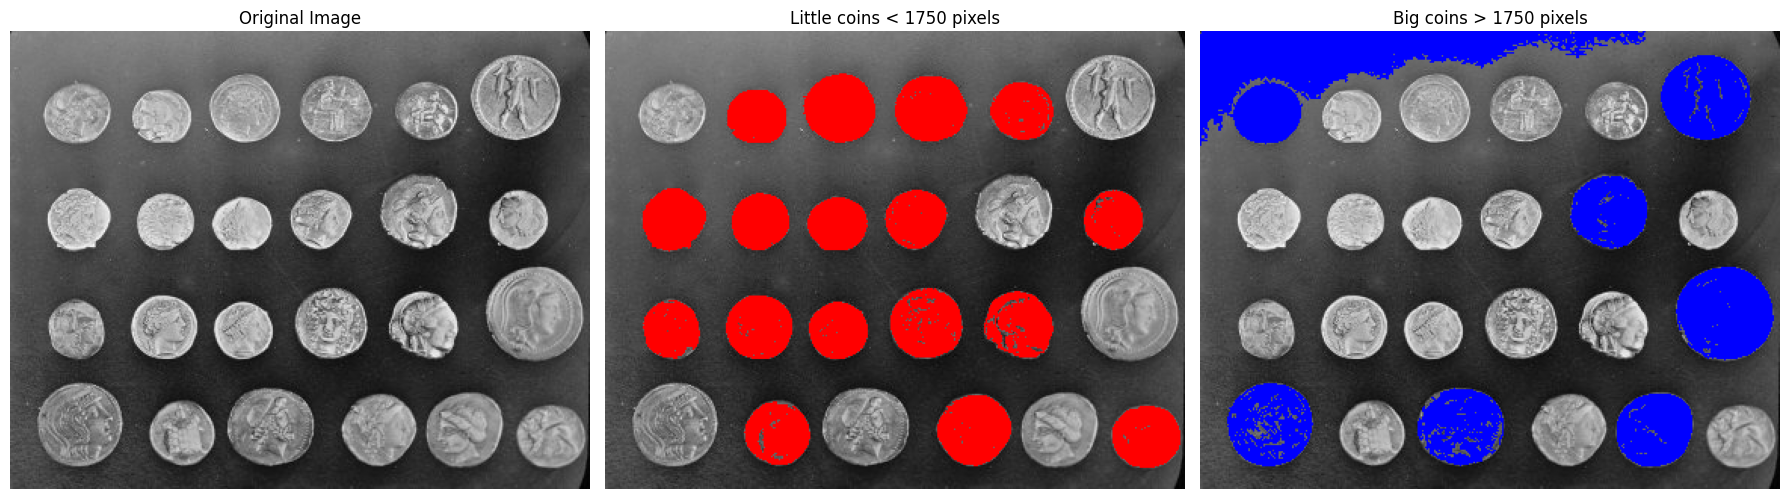

In [188]:
from skimage.color import gray2rgb
import numpy as np
import matplotlib.pyplot as plt

small_coin_labels = df_coins[df_coins["area"] < 1750]["label"].to_numpy()
big_coin_labels = df_coins[df_coins["area"] > 1750]["label"].to_numpy()

small_coin_mask = np.isin(labeled_coins, small_coin_labels)
big_coin_mask = np.isin(labeled_coins, big_coin_labels)

if image.ndim == 2:
    image_rgb = gray2rgb(image)
else:
    image_rgb = image.copy()

if image_rgb.max() > 1:
    image_rgb = image_rgb / 255

small_coins_image = image_rgb.copy()
big_coins_image = image_rgb.copy()

small_coins_image[small_coin_mask] = [1, 0, 0]
big_coins_image[big_coin_mask] = [0, 0, 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image_rgb)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(small_coins_image)
axes[1].set_title("Little coins < 1750 pixels")
axes[1].axis("off")

axes[2].imshow(big_coins_image)
axes[2].set_title("Big coins > 1750 pixels")
axes[2].axis("off")

plt.tight_layout()
plt.show()

9. Describe the main steps required to perform segmentation of an RGB image using an unsupervised clustering algorithm (use other algorithms different than K-Means and compare the results)

To perform segmentation of an RGB image using an unsupervised clustering algorithm, the image is first loaded and each pixel is represented as a feature vector containing its color values ((R,G,B)). The image is then reshaped into a 2D matrix where each row corresponds to a pixel. In some cases, spatial coordinates ((x,y)) are also included to preserve image structure. Before clustering, the features are usually normalized to improve performance.

Different clustering algorithms can then be applied to group pixels with similar characteristics. Besides K-Means, algorithms such as Gaussian Mixture Models (GMM), Mean Shift, and Agglomerative Clustering can also be used. GMM produces smoother segmentation because it assigns pixels probabilistically to clusters. Mean Shift groups pixels based on density and can automatically determine the number of clusters. Agglomerative Clustering merges similar regions hierarchically and often produces more separated segments.

Finally, the cluster labels are reshaped back to the original image dimensions to visualize the segmented image, where each cluster represents a different image region. Compared to K-Means, these methods may provide smoother or more structured segmentation results, although they are generally more computationally expensive.


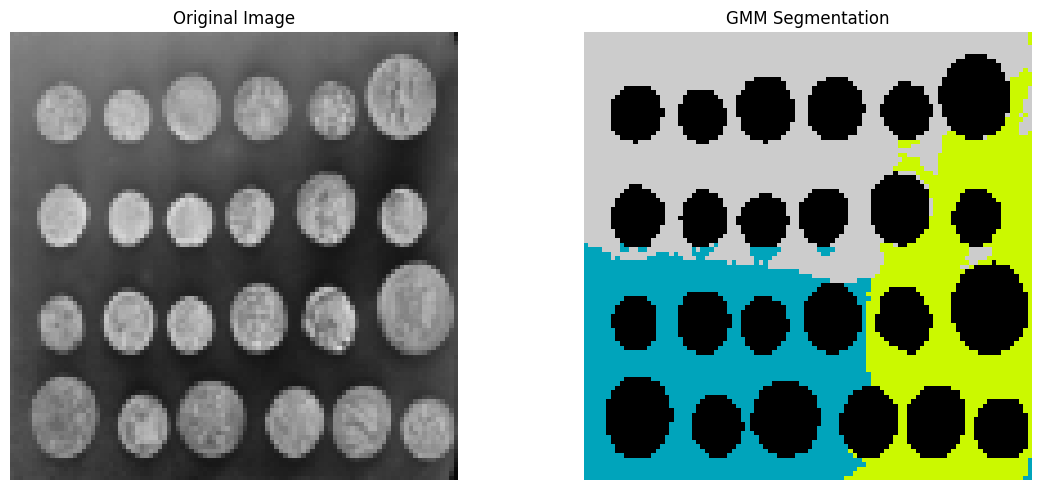

In [189]:
from skimage import data
from skimage.color import gray2rgb
from skimage.transform import resize
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt

image = gray2rgb(data.coins())
image_small = resize(image, (100, 100), anti_aliasing=True)
h, w, c = image_small.shape

pixels = image_small.reshape(-1, 3)

x_coords, y_coords = np.meshgrid(np.arange(w), np.arange(h))
spatial = np.stack([x_coords.ravel(), y_coords.ravel()], axis=1)
features = np.hstack((pixels, spatial))

features_std = StandardScaler().fit_transform(features)


gmm = GaussianMixture(n_components=4, random_state=0)
labels_gmm = gmm.fit_predict(features_std)

seg_gmm = labels_gmm.reshape(h, w)


fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].imshow(image_small)
axs[0].set_title("Original Image")
axs[0].axis('off')

axs[1].imshow(seg_gmm, cmap='nipy_spectral')
axs[1].set_title("GMM Segmentation")
axs[1].axis('off')

plt.tight_layout()
plt.show()

10. Extract the main texture features of this image

In [190]:
import pandas as pd
import numpy as np
from skimage.color import rgb2gray
from skimage.feature.texture import graycomatrix, graycoprops
from skimage import img_as_ubyte

if image.ndim == 3:
    coins = rgb2gray(image)
else:
    coins = image

coins_uint8 = img_as_ubyte(coins)

coins_quantized = (coins_uint8 / 16).astype(np.uint8)

glcm = graycomatrix(
    coins_quantized,
    distances=[1],
    angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
    levels=16,
    symmetric=True,
    normed=True
)

texture_features = {
    'Contrast': graycoprops(glcm, 'contrast')[0],
    'Dissimilarity': graycoprops(glcm, 'dissimilarity')[0],
    'Homogeneity': graycoprops(glcm, 'homogeneity')[0],
    'Energy': graycoprops(glcm, 'energy')[0],
    'Correlation': graycoprops(glcm, 'correlation')[0],
    'ASM': graycoprops(glcm, 'ASM')[0]
}

df_texture = pd.DataFrame(
    texture_features,
    index=['0°', '45°', '90°', '135°']
)

print("Main GLCM Texture Features:")
print(df_texture)

Main GLCM Texture Features:
      Contrast  Dissimilarity  Homogeneity    Energy  Correlation       ASM
0°    1.504632       0.579729     0.779863  0.223934     0.931803  0.050146
45°   2.213892       0.726921     0.741439  0.210277     0.899797  0.044216
90°   1.438906       0.584704     0.774033  0.219120     0.934790  0.048014
135°  2.195935       0.722814     0.742499  0.210340     0.900609  0.044243


Personal discussion:
With what I have learned so far about artificial intelligence, I can say that these past three days of lessons have already given me a strong and meaningful introduction to the field. Even though I was not able to attend every class because of work commitments, I still feel that I have gained valuable and practical knowledge that helped me better understand the basics.

What has stood out to me the most is computer vision, which I find to be the most fascinating subfield of AI so far. The idea that machines can be trained to “see” and interpret the world in a way similar to humans is especially interesting to me.

Although three days are not enough to fully explore such a complex topic and the course is quite intensive, I really appreciate that the focus has been on the practical side. Working hands-on has made the learning experience more engaging and easier to connect with real-world applications.
